##### Análisis y Procesamiento de Señales
# Trabajo Semanal n°0: Señal senoidal con diferentes parámetros utilizando funciones de python.
### hecho por Tomás Ladiani ([git](https://github.com/TLadiani))


La *frecuencia de Nyquist* es la frecuencia máxima que un sistema digital puede registrar de forma correcta. Es igual a la mitad de la frecuencia de muestreo [\(*fs* / 2\)].
Si una señal tiene frecuencias mayores a este límite, se deforma y aparecen errores extraños...

librerías y definiciones:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#%% Definiciones
"""
vmax = amplitud máxima de la senoidal (volts)
dc = su valor medio (volts)
ff = la frecuencia (Hz)
ph = la fase (radianes)
nn = la cantidad de muestras digitalizada por el ADC (# muestras)
fs = la frecuencia de muestreo del ADC.

Ts = 1/fs

#tt, xx = mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs)

"""

fs = 1000   #Hz
N = 1000    #muestras
vmax = 1.5
dc = 0
ff = 1
ph = 0

Función para crear la senoidal según parametros:

In [2]:
#%% Funciones
def mi_funcion_sen(vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs):
    
    tt = np.arange(0,nn) / fs
    
    xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc
    
    return(tt, xx)

Para fs y N predefinidos se prueban diferentes frecuencias:

- ff_1 = 500 Hz
- ff_2 = 999 Hz
- ff_3 = 1001 Hz
- ff_4 = 2001 Hz

Si la frecuencia de muestreo es de 1000 Hz, la frecuencia de Nyquist es de 500 Hz. Cualquier señal con una frecuencia mayor a este límite sufrirá el efecto de solapamiento y el sistema digital la interpretará como una frecuencia falsa e inferior dentro del rango de 0 a 500 Hz.

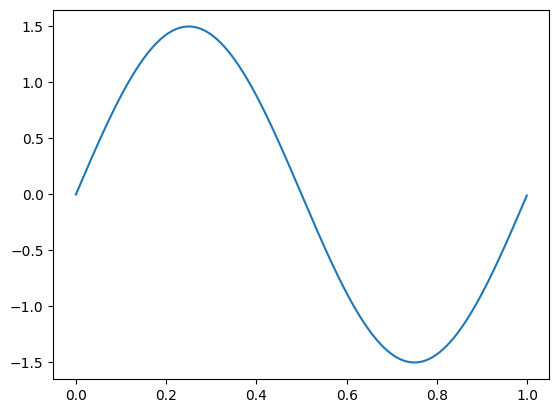

In [3]:
ff = 1
nn = np.arange(N)

tt,xx=mi_funcion_sen(vmax,dc,ff,ph,N,fs)


plt.plot(tt,xx)
plt.show()
#Reconstrucción perfecta: Se ve una onda senoidal limpia que completa exactamente 1 ciclo entero.

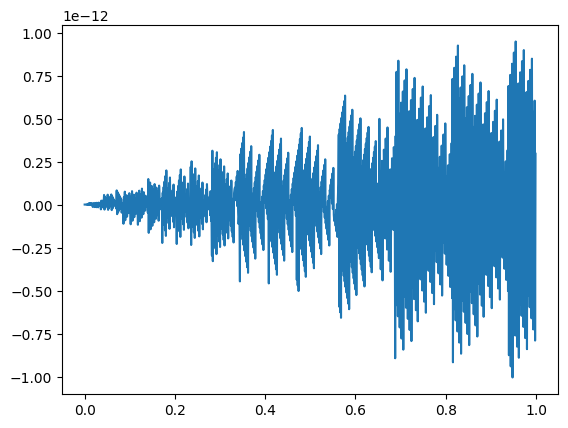

In [4]:
ff_1 = 500
nn = np.arange(N)

tt,xx=mi_funcion_sen(vmax,dc,ff_1,ph,N,fs)


plt.plot(tt,xx)
plt.show()
#Línea plana en 0V: Como la fase es 0 las muestras caen exactamente en los cruces por cero (\(\sin(0)\), \(\sin(\pi)\), etc.). La señal desaparece por completo.
#obs: si la escala de mi grafico fuese mas grande se vería una linea recta sobre 0.

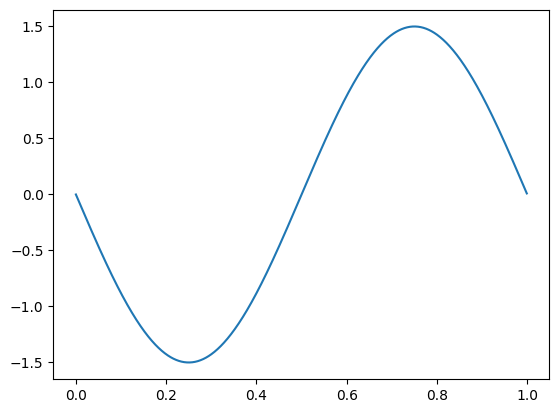

In [5]:
ff_2 = 999
nn = np.arange(N)

tt,xx=mi_funcion_sen(vmax,dc,ff_2,ph,N,fs)


plt.plot(tt,xx)
plt.show()
#Senoidal invertida: Se reconstruye una señal de 1 Hz pero dada vuelta debido a que el muestreo "va hacia atrás" respecto al ciclo.

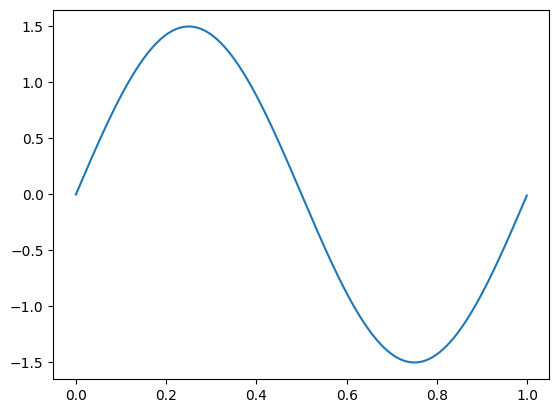

In [6]:
ff_3 = 1001
nn = np.arange(N)

tt,xx=mi_funcion_sen(vmax,dc,ff_3,ph,N,fs)


plt.plot(tt,xx)
plt.show()
#Senoidal idéntica a la de 1 Hz: El muestreo avanza un ciclo completo más una pequeña fracción, volviéndose indistinguible del caso a.

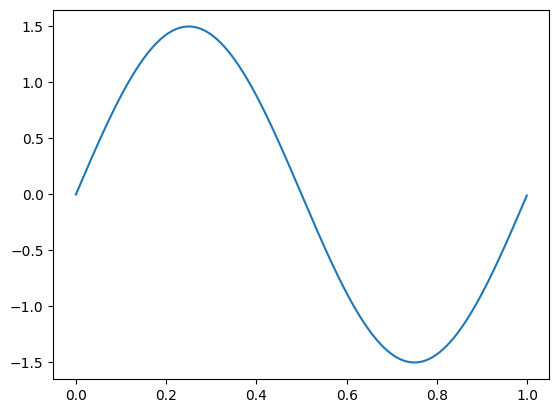

In [7]:
ff_4 = 2001
nn = np.arange(N)

tt,xx=mi_funcion_sen(vmax,dc,ff_4,ph,N,fs)


plt.plot(tt,xx)
plt.show()
#Senoidal idéntica a la de 1 Hz: El muestreo avanza 2 ciclos completos, replicando exactamente el caso de 1 Hz.